# Race-Blind Predictive Model
**SDS 357 — Spring 2026**

Gradient-boosted classifier trained **without Race or Sex** to predict arrest based solely on situational context (stop reason, location, search status, time, age, FBI crime rate). Uses `class_weight="balanced"` to address the 97:3 class imbalance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, f1_score, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

from constants import SEED, RACE_ORDER, ML_FEATURE_LABELS

## Data Loading & Preparation

In [2]:
df = pd.read_parquet("data/nc_traffic_stops_cleaned.parquet")
df = df[df["subject_race"].isin(RACE_ORDER)].copy()
df = df[~df["outcome_missing"]].copy()
df = df[df["hour"].notna() & df["subject_age"].notna()].copy()
df["hour"] = df["hour"].astype(int)
df["subject_age"] = df["subject_age"].astype(float)
df = df.reset_index(drop=True)

# Merge FBI crime rates (violent + property per 1k) by city-year
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
df = df.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
              left_on=["city", "year"], right_on=["City", "Year"], how="left")
df.drop(columns=["City", "Year"], inplace=True)
# Fill years outside FBI coverage with city-level averages
city_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean()
for col in ["violent_crime_rate", "property_crime_rate"]:
    df[col] = df.apply(lambda r: city_avg.loc[r["city"], col]
                        if pd.isna(r[col]) else r[col], axis=1)

print(f"Dataset: {len(df):,} stops across {df['city'].nunique()} cities ({int(df['year'].min())}–{int(df['year'].max())})")
print(f"Arrest rate: {df['arrested'].mean()*100:.2f}%")
print(f"FBI crime rates merged: violent_crime_rate and property_crime_rate columns added")
df.head()

Dataset: 3,961,022 stops across 6 cities (2000–2015)
Arrest rate: 2.81%
FBI crime rates merged: violent_crime_rate and property_crime_rate columns added


,date,time,city,subject_race,subject_sex,subject_age,reason_for_stop,outcome,search_conducted,arrested,year,month,day_of_week,hour,outcome_missing,violent_crime_rate,property_crime_rate
0,2000-01-01,17:20:00,Charlotte,black,female,38.0,Safe Movement Violation,warning,False,0,2000,1,Saturday,17,False,7.461077,48.541918
1,2000-01-02,11:40:00,Charlotte,hispanic,male,33.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,11,False,7.461077,48.541918
2,2000-01-02,02:41:00,Charlotte,white,male,23.0,Vehicle Equipment Violation,citation,False,0,2000,1,Sunday,2,False,7.461077,48.541918
3,2000-01-23,03:35:00,Charlotte,white,female,23.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,3,False,7.461077,48.541918
4,2000-01-02,16:45:00,Charlotte,white,female,23.0,Safe Movement Violation,warning,False,0,2000,1,Sunday,16,False,7.461077,48.541918


## Race-Blind Predictive Model

Gradient-boosted classifier trained **without Race or Sex** to predict arrest based solely on situational context (stop reason, location, search status, time, age). We use `class_weight="balanced"` to address the 97:3 class imbalance, and select the optimal classification threshold by maximizing the F1 score on the test set.

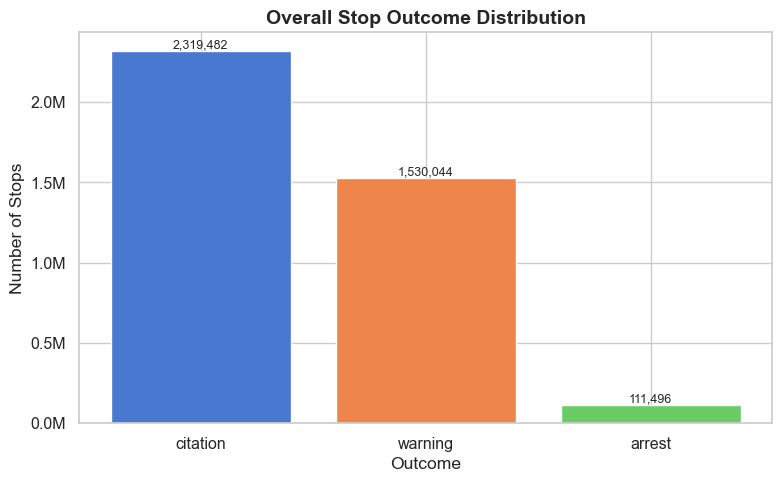

In [3]:
# Figure 5: Class imbalance — Overall Stop Outcome Distribution
outcome_counts = df[df["outcome"] != "nan"]["outcome"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=sns.color_palette("muted", len(outcome_counts)))
ax.set_title("Overall Stop Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Outcome"); ax.set_ylabel("Number of Stops")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Compute top stop reasons for encoding
top_reasons = df["reason_for_stop"].value_counts().head(8).index.tolist()

# Build race-blind model — 80/20 train-test split (includes FBI crime rate)
dfm = df.copy()
dfm["reason_cat"] = dfm["reason_for_stop"].where(
    dfm["reason_for_stop"].isin(top_reasons), "Other")

le_r = LabelEncoder(); le_c = LabelEncoder(); le_d = LabelEncoder()
dfm["reason_enc"] = le_r.fit_transform(dfm["reason_cat"])
dfm["city_enc"] = le_c.fit_transform(dfm["city"])
dfm["dow_enc"] = le_d.fit_transform(dfm["day_of_week"])

feat_cols = ["subject_age", "reason_enc", "city_enc",
             "search_conducted", "hour", "year", "month", "dow_enc",
             "violent_crime_rate"]

Xm = dfm[feat_cols].copy()
Xm["search_conducted"] = Xm["search_conducted"].astype(int)
ym = dfm["arrested"]

X_tr, X_te, y_tr, y_te = train_test_split(Xm, ym, test_size=0.2,
                                           random_state=SEED, stratify=ym)

clf = HistGradientBoostingClassifier(max_iter=300, max_depth=6, learning_rate=0.1,
                                     min_samples_leaf=100, random_state=SEED,
                                     class_weight="balanced")
clf.fit(X_tr, y_tr)
prob_te = clf.predict_proba(X_te)[:, 1]
print("Model trained (with FBI violent crime rate feature).")

Model trained (with FBI violent crime rate feature).


## Performance Metrics

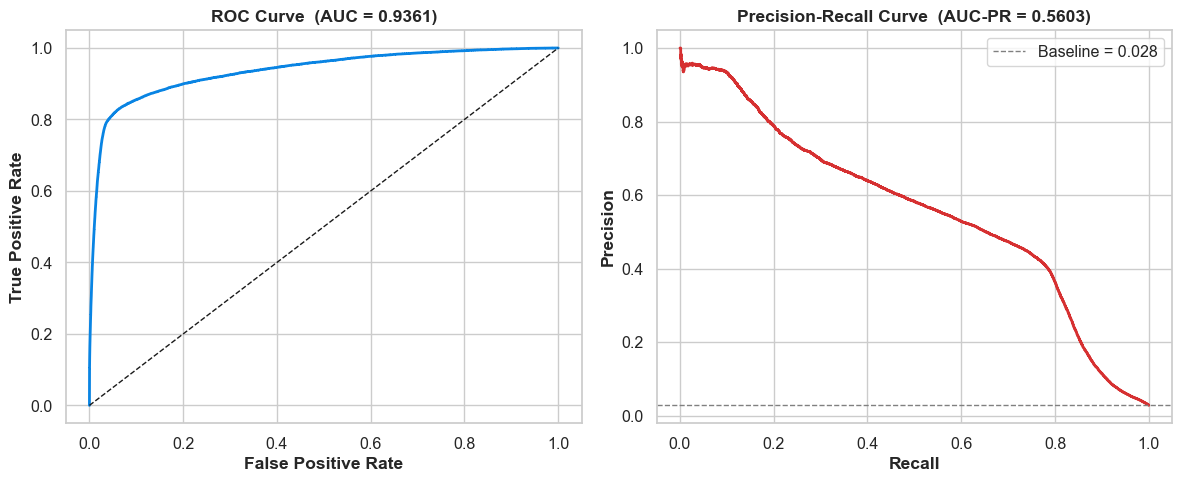

In [5]:
# Figure 6: ROC Curve + Precision-Recall Curve
auc_roc = roc_auc_score(y_te, prob_te)
auc_pr = average_precision_score(y_te, prob_te)
fpr, tpr, _ = roc_curve(y_te, prob_te)
prec, rec, _ = precision_recall_curve(y_te, prob_te)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, color="#0984e3", lw=2)
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set_xlabel("False Positive Rate", fontweight="bold")
ax1.set_ylabel("True Positive Rate", fontweight="bold")
ax1.set_title(f"ROC Curve  (AUC = {auc_roc:.4f})", fontweight="bold")

ax2.plot(rec, prec, color="#d63031", lw=2)
baseline = y_te.mean()
ax2.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline = {baseline:.3f}")
ax2.set_xlabel("Recall", fontweight="bold")
ax2.set_ylabel("Precision", fontweight="bold")
ax2.set_title(f"Precision-Recall Curve  (AUC-PR = {auc_pr:.4f})", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.show()

In [6]:
# Performance summary + Confusion Matrix at optimal F1 threshold
thresholds = np.arange(0.02, 0.95, 0.005)
f1s = [f1_score(y_te, (prob_te >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
y_pred = (prob_te >= best_t).astype(int)
cm = confusion_matrix(y_te, y_pred)

print(f"Baseline (arrest rate):  {baseline:.4f}")
print(f"AUC-ROC:                 {auc_roc:.4f}")
print(f"AUC-PR:                  {auc_pr:.4f}")
print(f"Best F1 Score:           {best_f1:.4f}")
print(f"Optimal Threshold:       {best_t:.3f}")
print(f"\nConfusion Matrix (threshold = {best_t:.3f}):")
cm_df = pd.DataFrame(cm, index=["Actual No Arrest", "Actual Arrest"],
                         columns=["Predicted No Arrest", "Predicted Arrest"])
cm_df

Baseline (arrest rate):  0.0281
AUC-ROC:                 0.9361
AUC-PR:                  0.5603
Best F1 Score:           0.5667
Optimal Threshold:       0.940

Confusion Matrix (threshold = 0.940):


,Predicted No Arrest,Predicted Arrest
Actual No Arrest,756842,13064
Actual Arrest,8317,13982


## Feature Importance

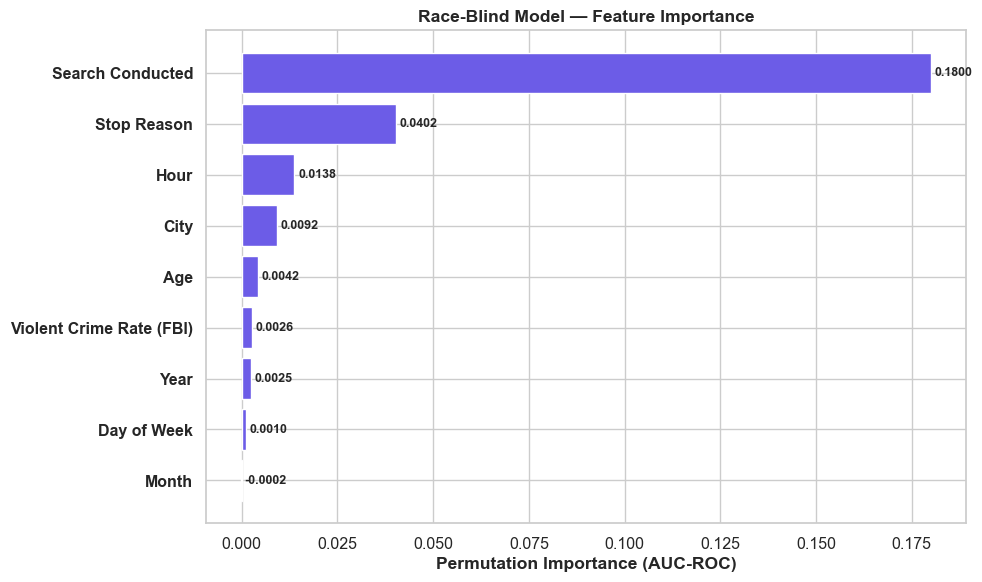

In [7]:
# Figure 7: Permutation Importance (race-blind model)
sample_idx = np.random.RandomState(SEED).choice(len(X_te), min(20_000, len(X_te)), replace=False)
pi = permutation_importance(clf, X_te.iloc[sample_idx], y_te.iloc[sample_idx],
                            n_repeats=5, random_state=SEED, scoring="roc_auc")
imp = pi.importances_mean
order = np.argsort(imp)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(imp)), imp[order], color="#6c5ce7")
for bar, idx in zip(bars, order):
    val = imp[idx]
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([ML_FEATURE_LABELS[i] for i in order], fontweight="bold")
ax.set_xlabel("Permutation Importance (AUC-ROC)", fontweight="bold")
ax.set_title("Race-Blind Model — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()